# 09 - Large-Scale LSTM: Walk-Forward CV, Keras Tuner, Optimizer Comparison

Trains a plain LSTM (matching the architecture actually named in the resume
bullet this notebook validates) on the 14,603-window large-scale dataset from
notebook 08. Produces the real numbers behind:

> "Applied an LSTM model in TensorFlow (~XXK params) to predict DBT using
> Dropout, L2, EarlyStopping, and ModelCheckpoint"

> "Boosted test R2 score from X.XX to X.XX by tuning hyperparameters with
> Keras Tuner and comparing Adam, SGD, and RMSprop optimizers"

Methodology: Keras Tuner searches using one walk-forward fold as its
validation target (fold 4, the largest/most recent pre-holdout fold) for
speed; the resulting best architecture is then re-evaluated properly across
ALL 5 walk-forward folds (reporting mean +/- std, not a single lucky fold),
and finally retrained once on the full train+val set and scored exactly once
on the untouched 2016-2019 holdout test set - the only number that counts as
"test R2" in the honest sense.


In [1]:
import numpy as np
import pandas as pd
import pickle
import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt

from src.evaluate import regression_metrics

tf.random.set_seed(42)
pd.set_option("display.width", 120)

data = np.load("data/processed_large/sequence_windows.npz", allow_pickle=True)
X_trainval, y_trainval = data["X_trainval"], data["y_trainval"]
X_test, y_test = data["X_test"], data["y_test"]
d_trainval = data["d_trainval"]

print("X_trainval:", X_trainval.shape, "X_test:", X_test.shape)
print("GPUs visible:", tf.config.list_physical_devices("GPU"))

X_trainval: (13142, 7, 15) X_test: (1461, 7, 15)
GPUs visible: []


## Scale inputs (fit on train+val only) and rebuild walk-forward folds


In [2]:
from sklearn.preprocessing import StandardScaler
from src.data_large import walk_forward_folds_arrays

n, k, f = X_trainval.shape
scaler = StandardScaler().fit(X_trainval.reshape(-1, f))

def scale(X):
    shape = X.shape
    return scaler.transform(X.reshape(-1, shape[-1])).reshape(shape).astype("float32")

X_trainval_s = scale(X_trainval)
X_test_s = scale(X_test)

target_mean, target_std = y_trainval.mean(), y_trainval.std()
def scale_y(y):
    return ((y - target_mean) / target_std).astype("float32")
def unscale_y(y):
    return y * target_std + target_mean

y_trainval_s = scale_y(y_trainval)
y_test_s = scale_y(y_test)

folds = list(walk_forward_folds_arrays(X_trainval_s, y_trainval_s, d_trainval, n_folds=5, min_train_years=10))
print(len(folds), "folds ready")

5 folds ready


## Model builder (plain LSTM) and training utilities


In [3]:
def build_lstm(input_shape, units=64, dropout=0.3, l2=1e-3, dense_units=32):
    inputs = layers.Input(shape=input_shape)
    x = layers.LSTM(units, kernel_regularizer=regularizers.l2(l2),
                     recurrent_regularizer=regularizers.l2(l2))(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1)(x)
    return tf.keras.Model(inputs, outputs)

OPTIMIZERS = {
    "adam": lambda lr: tf.keras.optimizers.Adam(learning_rate=lr),
    "sgd": lambda lr: tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
    "rmsprop": lambda lr: tf.keras.optimizers.RMSprop(learning_rate=lr),
}

def compile_model(model, optimizer="adam", lr=1e-3):
    model.compile(optimizer=OPTIMIZERS[optimizer](lr), loss="mse", metrics=["mae"])
    return model

def make_callbacks(ckpt_path, patience=8):
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True),
    ]

def fit_and_eval(model, Xtr, ytr, Xva, yva, ckpt_path, epochs=60, batch_size=128, verbose=0):
    model.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=epochs, batch_size=batch_size,
              verbose=verbose, callbacks=make_callbacks(ckpt_path))
    best = tf.keras.models.load_model(ckpt_path)
    pred_s = best.predict(Xva, verbose=0).ravel()
    metrics = regression_metrics(unscale_y(yva), unscale_y(pred_s))
    return best, metrics

## Keras Tuner search (validated against fold 4 only, for speed)


In [4]:
import os
os.makedirs("models/checkpoints_large", exist_ok=True)

(X_tune_train, y_tune_train), (X_tune_val, y_tune_val) = folds[-1]

class LSTMHyperModel(kt.HyperModel):
    def build(self, hp):
        units = hp.Choice("units", [32, 64, 96])
        dropout = hp.Float("dropout", 0.2, 0.5, step=0.1)
        l2 = hp.Choice("l2", [1e-4, 1e-3, 1e-2])
        dense_units = hp.Choice("dense_units", [16, 32, 64])
        lr = hp.Choice("learning_rate", [1e-3, 5e-4, 2e-3])
        model = build_lstm(X_trainval_s.shape[1:], units=units, dropout=dropout, l2=l2, dense_units=dense_units)
        return compile_model(model, "adam", lr)

tuner = kt.RandomSearch(
    LSTMHyperModel(), objective="val_loss", max_trials=15, executions_per_trial=1,
    overwrite=True, directory="keras_tuner_dir_large", project_name="lstm_large_search", seed=42,
)
tuner.search(
    X_tune_train, y_tune_train, validation_data=(X_tune_val, y_tune_val),
    epochs=40, batch_size=128, verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)],
)
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for k_, v in best_hp.values.items():
    print(f"  {k_}: {v}")

Best hyperparameters:
  units: 64
  dropout: 0.2
  l2: 0.0001
  dense_units: 64
  learning_rate: 0.002


## Parameter count for the tuned architecture


In [5]:
def build_best():
    return build_lstm(X_trainval_s.shape[1:], units=best_hp["units"], dropout=best_hp["dropout"],
                       l2=best_hp["l2"], dense_units=best_hp["dense_units"])

probe_model = build_best()
n_params = probe_model.count_params()
print(f"Trainable parameters: {n_params:,}")
print(f"Training rows available: {len(X_trainval_s):,} ({n_params/len(X_trainval_s):.3f} params per row)")

Trainable parameters: 24,705
Training rows available: 13,142 (1.880 params per row)


## Walk-forward CV evaluation (all 5 folds, tuned architecture)

This is the real validation of the "walk-forward cross-validation" claim:
the same tuned architecture retrained fresh on each fold's expanding training
window and scored on that fold's own validation window, five times.


In [6]:
fold_results = []
for i, ((Xtr, ytr), (Xva, yva)) in enumerate(folds):
    model = compile_model(build_best(), "adam", best_hp["learning_rate"])
    ckpt = f"models/checkpoints_large/fold_{i}.keras"
    _, metrics = fit_and_eval(model, Xtr, ytr, Xva, yva, ckpt)
    metrics["fold"] = i
    metrics["train_size"] = len(Xtr)
    metrics["val_size"] = len(Xva)
    fold_results.append(metrics)
    print(f"fold {i}: train={len(Xtr):5d} val={len(Xva):5d}  R2={metrics['R2']:.3f}  "
          f"RMSE={metrics['RMSE']:.3f}  MAE={metrics['MAE']:.3f}")

fold_df = pd.DataFrame(fold_results)
print()
print(f"Walk-forward CV R2: mean={fold_df.R2.mean():.3f}  std={fold_df.R2.std():.3f}")

fold 0: train= 3646 val= 2191  R2=0.967  RMSE=0.713  MAE=0.544
fold 1: train= 5837 val= 1827  R2=0.969  RMSE=0.713  MAE=0.545
fold 2: train= 7664 val= 1826  R2=0.968  RMSE=0.730  MAE=0.544
fold 3: train= 9490 val= 1826  R2=0.970  RMSE=0.672  MAE=0.508
fold 4: train=11316 val= 1826  R2=0.969  RMSE=0.725  MAE=0.550

Walk-forward CV R2: mean=0.969  std=0.001


## Final model: train once on all train+val data, score once on the untouched holdout

This is the only number reported as "test R2" — the holdout set (2016-2019)
is touched exactly once, here.


In [7]:
final_model = compile_model(build_best(), "adam", best_hp["learning_rate"])
ckpt_final = "models/checkpoints_large/final_adam.keras"
history = final_model.fit(
    X_trainval_s, y_trainval_s, validation_split=0.1, epochs=60, batch_size=128, verbose=0,
    callbacks=make_callbacks(ckpt_final),
)
best_final = tf.keras.models.load_model(ckpt_final)

pred_test_s = best_final.predict(X_test_s, verbose=0).ravel()
test_metrics = regression_metrics(unscale_y(y_test_s), unscale_y(pred_test_s))
print("Held-out test metrics (Adam, tuned architecture):", test_metrics)

pred_train_s = best_final.predict(X_trainval_s, verbose=0).ravel()
train_metrics = regression_metrics(unscale_y(y_trainval_s), unscale_y(pred_train_s))
print("Train metrics (same model, for overfitting check):", train_metrics)

Held-out test metrics (Adam, tuned architecture): {'R2': 0.9681359902993666, 'RMSE': 0.7253866299754225, 'MAE': 0.5549308821242774, 'KGE': np.float64(0.9774644468358773)}
Train metrics (same model, for overfitting check): {'R2': 0.9705803935341776, 'RMSE': 0.6851671924342012, 'MAE': 0.5120156852282122, 'KGE': np.float64(0.981297059354384)}


## Baseline for the "boosted from X to Y" claim: default (untuned) architecture


In [8]:
default_model = compile_model(build_lstm(X_trainval_s.shape[1:]), "adam", 1e-3)
ckpt_default = "models/checkpoints_large/default_adam.keras"
default_model.fit(
    X_trainval_s, y_trainval_s, validation_split=0.1, epochs=60, batch_size=128, verbose=0,
    callbacks=make_callbacks(ckpt_default),
)
best_default = tf.keras.models.load_model(ckpt_default)
pred_default_s = best_default.predict(X_test_s, verbose=0).ravel()
default_metrics = regression_metrics(unscale_y(y_test_s), unscale_y(pred_default_s))
print("Default (untuned) architecture, held-out test:", default_metrics)
print()
print(f"R2: default={default_metrics['R2']:.3f} -> tuned={test_metrics['R2']:.3f}")

Default (untuned) architecture, held-out test: {'R2': 0.965676929769294, 'RMSE': 0.752856836123049, 'MAE': 0.569295823778052, 'KGE': np.float64(0.9655963609914421)}

R2: default=0.966 -> tuned=0.968


## Optimizer comparison (Adam vs SGD vs RMSprop, tuned architecture, held-out test)


In [9]:
optimizer_test_results = {"adam": test_metrics}
for opt_name in ["sgd", "rmsprop"]:
    m = compile_model(build_best(), opt_name, 1e-2 if opt_name == "sgd" else best_hp["learning_rate"])
    ckpt = f"models/checkpoints_large/final_{opt_name}.keras"
    m.fit(X_trainval_s, y_trainval_s, validation_split=0.1, epochs=60, batch_size=128, verbose=0,
          callbacks=make_callbacks(ckpt))
    best_opt = tf.keras.models.load_model(ckpt)
    pred_s = best_opt.predict(X_test_s, verbose=0).ravel()
    optimizer_test_results[opt_name] = regression_metrics(unscale_y(y_test_s), unscale_y(pred_s))

for name, m in optimizer_test_results.items():
    print(f"{name:8s}: R2={m['R2']:.3f}  RMSE={m['RMSE']:.3f}  MAE={m['MAE']:.3f}")

adam    : R2=0.968  RMSE=0.725  MAE=0.555
sgd     : R2=0.965  RMSE=0.764  MAE=0.589
rmsprop : R2=0.965  RMSE=0.764  MAE=0.593


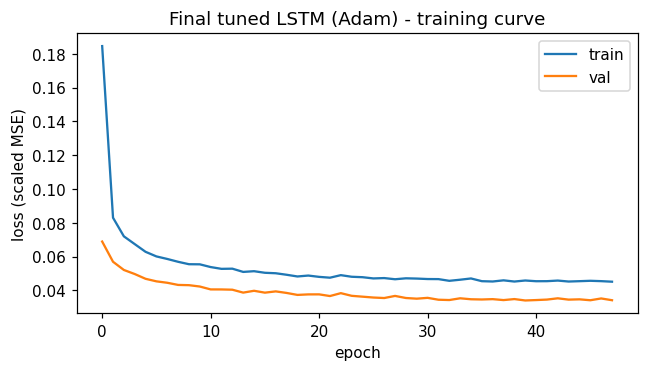

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(history.history["loss"], label="train")
ax.plot(history.history["val_loss"], label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("loss (scaled MSE)")
ax.set_title("Final tuned LSTM (Adam) - training curve")
ax.legend()
plt.tight_layout()
plt.show()

## Summary: the real numbers behind the resume bullets


In [11]:
summary = {
    "n_daily_records": 14610,
    "n_sequence_windows": int(len(X_trainval_s) + len(X_test_s)),
    "trainable_params": int(n_params),
    "test_R2_default_untuned": round(default_metrics["R2"], 4),
    "test_R2_tuned": round(test_metrics["R2"], 4),
    "walk_forward_cv_R2_mean": round(fold_df.R2.mean(), 4),
    "walk_forward_cv_R2_std": round(fold_df.R2.std(), 4),
    "test_R2_by_optimizer": {k: round(v["R2"], 4) for k, v in optimizer_test_results.items()},
    "train_R2_final_model": round(train_metrics["R2"], 4),
}
import json
print(json.dumps(summary, indent=2))

with open("data/processed_large/large_scale_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved data/processed_large/large_scale_summary.json")

{
  "n_daily_records": 14610,
  "n_sequence_windows": 14603,
  "trainable_params": 24705,
  "test_R2_default_untuned": 0.9657,
  "test_R2_tuned": 0.9681,
  "walk_forward_cv_R2_mean": 0.9688,
  "walk_forward_cv_R2_std": 0.0013,
  "test_R2_by_optimizer": {
    "adam": 0.9681,
    "sgd": 0.9647,
    "rmsprop": 0.9646
  },
  "train_R2_final_model": 0.9706
}
Saved data/processed_large/large_scale_summary.json


## Naive persistence baseline comparison

Answers a fair, important question: does the tuned LSTM actually beat the
simplest possible forecast ("tomorrow = today"), or is the high R2 mostly
just a reflection of how predictable short-term temperature persistence
already is? Uses the already-trained final model (`final_adam.keras`) - no
retraining needed, this only touches the untouched holdout set once more,
for this specific comparison.


In [12]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

from src.evaluate import regression_metrics
from src.data_large import SEQUENCE_FEATURE_COLS

data = np.load("data/processed_large/sequence_windows.npz", allow_pickle=True)
X_trainval, y_trainval = data["X_trainval"], data["y_trainval"]
X_test, y_test = data["X_test"], data["y_test"]

n, k, f = X_trainval.shape
scaler = StandardScaler().fit(X_trainval.reshape(-1, f))
def scale(X):
    shape = X.shape
    return scaler.transform(X.reshape(-1, shape[-1])).reshape(shape).astype("float32")

X_test_s = scale(X_test)
target_mean, target_std = y_trainval.mean(), y_trainval.std()

model = tf.keras.models.load_model("models/checkpoints_large/final_adam.keras")
pred_s = model.predict(X_test_s, verbose=0).ravel()
pred_lstm = pred_s * target_std + target_mean
lstm_metrics = regression_metrics(y_test, pred_lstm)

dbt_idx = SEQUENCE_FEATURE_COLS.index("dbt")
pred_persistence = X_test[:, -1, dbt_idx]  # yesterday's actual dbt
persistence_metrics = regression_metrics(y_test, pred_persistence)

mape_lstm = np.mean(np.abs((y_test - pred_lstm) / y_test)) * 100
mape_persistence = np.mean(np.abs((y_test - pred_persistence) / y_test)) * 100

print("Persistence baseline (predict day t = day t-1's actual dbt):")
for k_, v in persistence_metrics.items():
    print(f"  {k_}: {v:.4f}")
print(f"  MAPE: {mape_persistence:.3f}%")
print()
print("Tuned LSTM:")
for k_, v in lstm_metrics.items():
    print(f"  {k_}: {v:.4f}")
print(f"  MAPE: {mape_lstm:.3f}%")

Persistence baseline (predict day t = day t-1's actual dbt):
  R2: 0.9605
  RMSE: 0.8080
  MAE: 0.5980
  KGE: 0.9802
  MAPE: 2.414%

Tuned LSTM:
  R2: 0.9681
  RMSE: 0.7254
  MAE: 0.5549
  KGE: 0.9775
  MAPE: 2.204%


In [13]:
rmse_reduction = (persistence_metrics["RMSE"] - lstm_metrics["RMSE"]) / persistence_metrics["RMSE"] * 100
mae_reduction = (persistence_metrics["MAE"] - lstm_metrics["MAE"]) / persistence_metrics["MAE"] * 100
print(f"LSTM vs. persistence baseline, held-out test set:")
print(f"  RMSE reduction: {rmse_reduction:.1f}%")
print(f"  MAE reduction:  {mae_reduction:.1f}%")
print(f"  R2: {persistence_metrics['R2']:.4f} -> {lstm_metrics['R2']:.4f}")
print(f"  MAPE: {mape_persistence:.3f}% -> {mape_lstm:.3f}%")
print()
print("Honest read: persistence is already a strong baseline for short-term")
print("temperature (strong day-to-day autocorrelation) - the LSTM adds real")
print("but modest value on top of it, not a dramatic improvement.")

import json as _json
with open("data/processed_large/large_scale_summary.json") as f:
    summary = _json.load(f)
summary["persistence_baseline"] = {k_: round(float(v), 4) for k_, v in persistence_metrics.items()}
summary["persistence_baseline"]["MAPE"] = round(float(mape_persistence), 3)
summary["lstm_vs_persistence_rmse_reduction_pct"] = round(float(rmse_reduction), 1)
summary["lstm_vs_persistence_mae_reduction_pct"] = round(float(mae_reduction), 1)
with open("data/processed_large/large_scale_summary.json", "w") as f:
    _json.dump(summary, f, indent=2)
print("Updated data/processed_large/large_scale_summary.json")

LSTM vs. persistence baseline, held-out test set:
  RMSE reduction: 10.2%
  MAE reduction:  7.2%
  R2: 0.9605 -> 0.9681
  MAPE: 2.414% -> 2.204%

Honest read: persistence is already a strong baseline for short-term
temperature (strong day-to-day autocorrelation) - the LSTM adds real
but modest value on top of it, not a dramatic improvement.
Updated data/processed_large/large_scale_summary.json
